# Dataset Description
## Share of people that think mea should be the head of the household by group age

**Source**: DANE, Encuesta Nacional del Uso del Tiempo

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/pobreza-y-condiciones-de-vida/encuesta-nacional-del-uso-del-tiempo-enut)

# Code
## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [2]:
path = "./data/la_cabeza_del_hogar_debe_ser_el_hombre.csv"

cols = [
    "periodo",
    "grupo",
    "categoria",
    "sexo",
    "respuesta",
    "pct"
]
df = pd.read_csv(path, encoding="utf-8", usecols=cols)

## Clean data

In [3]:
df_f = df[
    df["grupo"].eq("Grupos de edad") &
    df["respuesta"].eq("Está muy de acuerdo")
].drop(columns=["grupo", "respuesta"])

df_f["periodo"] = df_f["periodo"].str.split(" ").str[4]
df_f["categoria"] = df_f["categoria"].str.replace(r"[^0-9]+", "-", regex=True).str.strip("-")
df_f["categoria"] = df_f["categoria"].replace("76", "76+")

male = df_f[df_f["sexo"].str.lower().eq("hombre")].drop(columns=["sexo"])
female = df_f[df_f["sexo"].str.lower().eq("mujer")].drop(columns=["sexo"])

## Plot

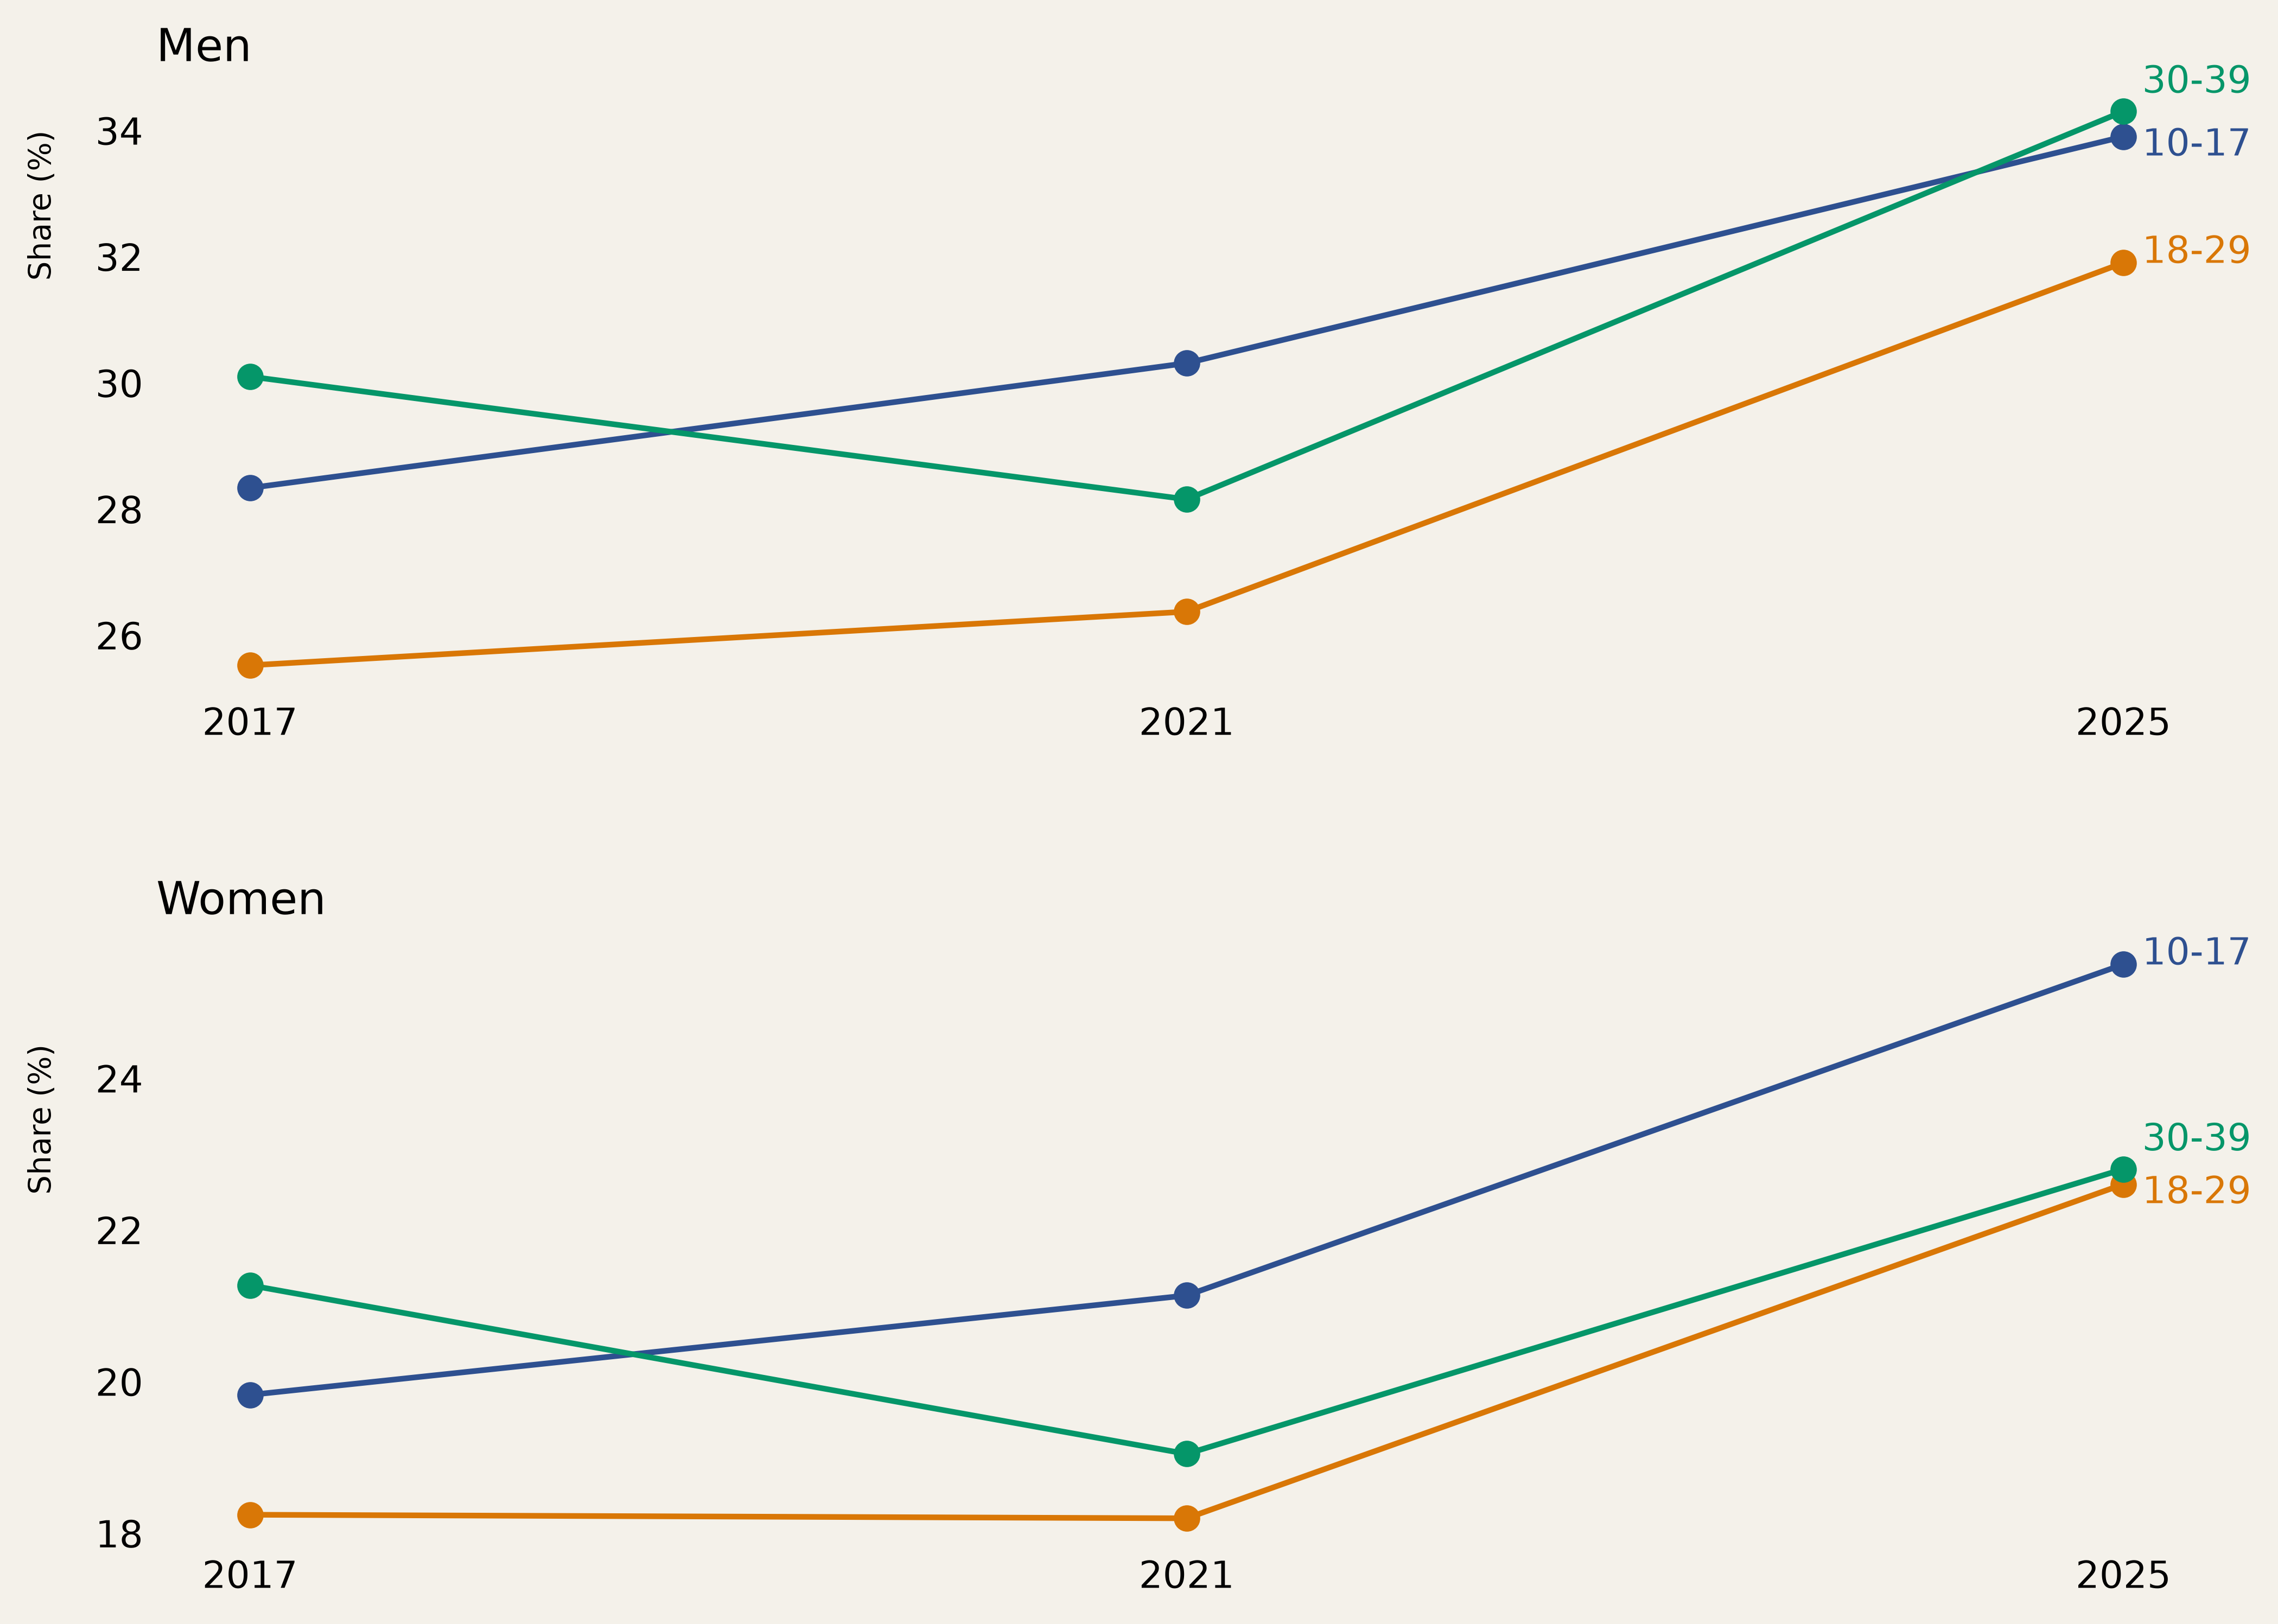

In [4]:
background = "#F4F1EA"
colors = {
    "10-17": "#2E5090",
    "18-29": "#D97706",
    "30-39": "#059669"
}

offset_mapping_ax1 = {
    "10-17": -5,
    "18-29": 0,
    "30-39": 5
}

offset_mapping_ax2 = {
    "10-17": 0,
    "18-29": -5,
    "30-39": 5
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax1.patch.set_facecolor(background)
ax2.patch.set_facecolor(background)

for age in male["categoria"].unique()[:3]:
    tmp = male[male["categoria"].eq(age)][["periodo", "pct"]].sort_values("periodo")

    ax1.plot(tmp["periodo"], tmp["pct"], color=colors[age], marker="o")

    offset_y = offset_mapping_ax1[age]
    ax1.annotate(
        f"{age}",
        xy=(tmp["periodo"].iloc[-1], tmp["pct"].iloc[-1]),
        color=colors[age],
        xytext=(5, offset_y),
        textcoords="offset points",
    )

for age in female["categoria"].unique()[:3]:
    tmp = female[female["categoria"].eq(age)][["periodo", "pct"]].sort_values("periodo")

    ax2.plot(tmp["periodo"], tmp["pct"], color=colors[age], marker="o")

    offset_y = offset_mapping_ax2[age]
    ax2.annotate(
        f"{age}",
        xy=(tmp["periodo"].iloc[-1], tmp["pct"].iloc[-1]),
        color=colors[age],
        xytext=(5, offset_y),
        textcoords="offset points",
    )

ax1.set_title("Men", loc="left")

ax1.set_ylabel("Share (%)", labelpad=10, fontsize=8, y=0.8)

for side in ["top", "bottom", "left", "right"]:
    ax1.spines[side].set_visible(False)

for axis in ["y", "x"]:
    ax1.tick_params(axis=axis, length=0)

ax2.set_title("Women", loc="left")

ax2.set_ylabel("Share (%)", labelpad=10, fontsize=8, y=0.7)

for side in ["top", "bottom", "left", "right"]:
    ax2.spines[side].set_visible(False)

for axis in ["y", "x"]:
    ax2.tick_params(axis=axis, length=0)

plt.subplots_adjust(hspace=0.4)
plt.show()